(1, 301, 162, 180, 360) (1, 301, 162, 180, 360)
pre 0.22769433
tar 0.2313986
ssta mse 0.007950661
162 vars mse 1232.7562


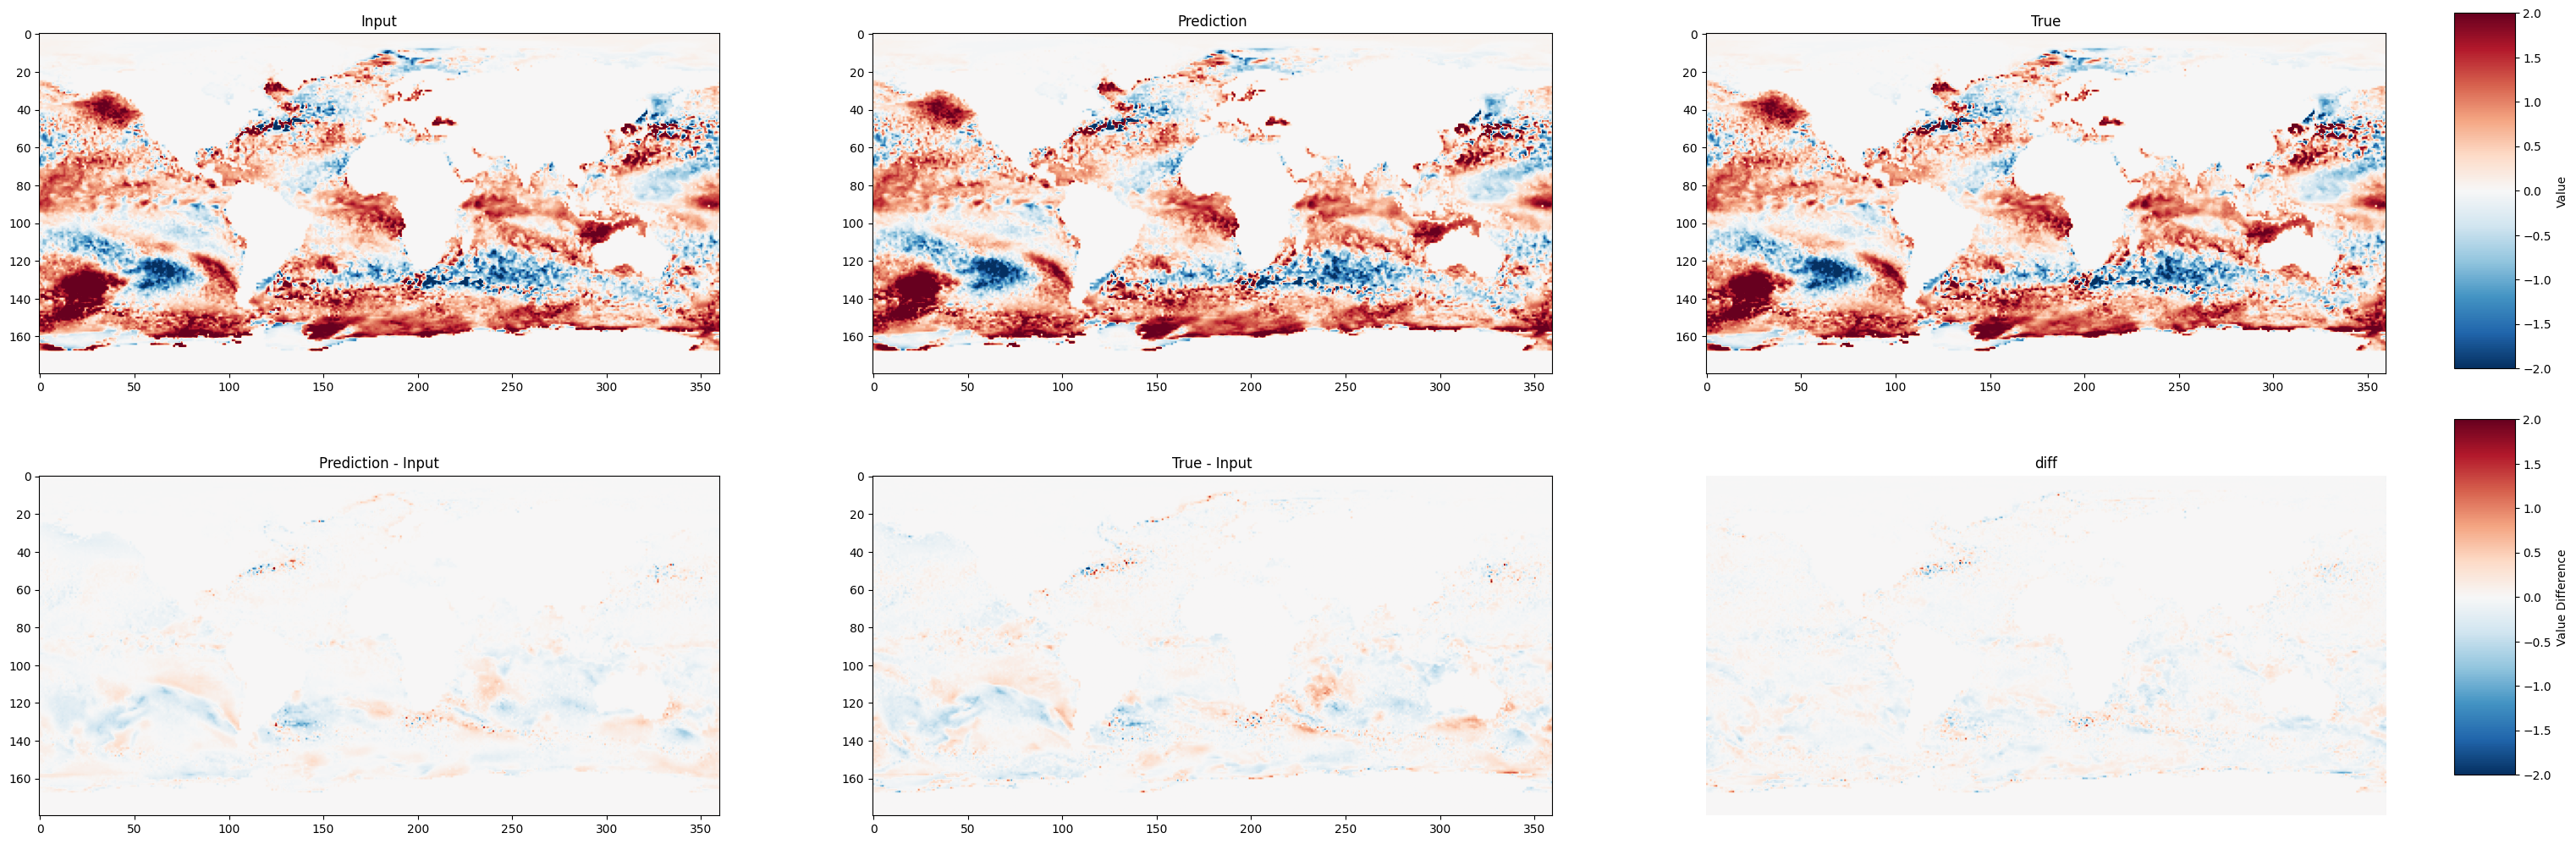

In [3]:
import matplotlib.pyplot as plt
import h5py
import torch
import torch.nn.functional as F
import numpy as np


def shift_image(data):
    width = data.shape[1]
    left_half = data[:, :width // 2]
    right_half = data[:, width // 2:]
    return np.concatenate((right_half, left_half), axis=1)


# ds = h5py.File('/jizhicfs/easyluwu/gaoyuan/CVPR2026_coupler/coupler_1degree/exp_15_levels_202312/DSLCast/20250601-132533/results_forecasting_55ics_icml_0.h5')
ds = h5py.File('/jizhicfs/easyluwu/gaoyuan/CVPR2026_coupler/coupler_1degree/exp_15_levels_202312/DSLCast/20250601-132533/results_forecasting_55ics_icml.h5')
# ds = h5py.File('/apdcephfs_qy3/share_301734960/easyluwu/gy/PnP-Corrector_github/correction_agent/exp/DSLCast/20250601-132533/results_forecasting_55ics_icml_0512.h5')
# ds = h5py.File('/apdcephfs_qy3/share_301734960/easyluwu/gy/CVPR2026_coupler_to_qy_rebuttal/coupler_1degree_rebuttal_0513/exp_15_levels_202312/DSLCast/20250601-132533/results_forecasting_55ics_icml.h5')
# ds = h5py.File('/apdcephfs_qy3/share_301734960/easyluwu/gy/PnP-Corrector_github/correction_agent/exp/DSLCast/20250601-132533/results_forecasting.h5')

# print(ds.keys())
time = 1
var = 138
ic = 0

print(ds['predicted'].shape, ds['ground_truth'].shape)


input = torch.tensor(ds['predicted'][ic, 0, var, :, :])
input = input.numpy()


pre = torch.tensor(ds['predicted'][ic, time, var, :, :])
pre = pre.numpy()
print('pre', np.mean(pre))


tar = torch.tensor(ds['ground_truth'][ic, time, var, :, :])
tar = tar.numpy()

print('tar', np.mean(tar))

print('ssta mse', np.mean((pre-tar)**2))

# mean = np.load('/jizhicfs/Prometheus/gaoyuan/llm/ft_local/data/weatherbench2/69var/mean.npy')
# std = np.load('/jizhicfs/Prometheus/gaoyuan/llm/ft_local/data/weatherbench2/69var/std.npy')
# mean = np.load('/jizhicfs/Prometheus/gaoyuan/llm/ft_local/data/weatherbench2/69var/mean_1975-1978_q_nan.npy')
# std = np.load('/jizhicfs/Prometheus/gaoyuan/llm/ft_local/data/weatherbench2/69var/std_1975-1978_q_nan.npy')
# preds = (ds['predicted'][0, time, :, :, :] - mean[:, :, :, :]) / std[:, :, :, :]
# tars = (ds['ground_truth'][0, time, :, :, :] - mean[:, :, :, :]) / std[:, :, :, :]
# mse = (preds - tars) ** 2
# print('all 69 vars normalized mse', np.mean(mse))

preds = ds['predicted'][0, time, :, :, :]
tars = ds['ground_truth'][0, time, :, :, :]
mse = (preds - tars) ** 2
print('162 vars mse', np.mean(mse))
value_range = 0


# min0 = -2500
# max0 = 2500
# min1 = -2500
# max1 = 2500


# min0 = 10000
# max0 = 500000
# min1 = -5000
# max1 = 5000

# min0 = -20
# max0 = 20
# min1 = -10
# max1 = 10

# min0 = 250
# max0 = 300
# min1 = -10
# max1 = 10

min0 = -2
max0 = 2
min1 = -2
max1 = 2

# min0 = 0.001
# max0 = 0.01
# min1 = -0.002
# max1 = 0.002


# min0 = 230000
# max0 = 240000
# min1 = -3000
# max1 = 3000

#mslp
# min0 = 96000
# max0 = 104000
# min1 = -3000
# max1 = 3000


if value_range == 0:
    # 设置绘图
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(36, 12))


    # 使用 imshow 绘制图像
    img_inputs = axes[0, 0].imshow(input, cmap='RdBu_r', vmin=min0, vmax=max0)
    axes[0, 0].set_title('Input')


    img_preds = axes[0, 1].imshow(pre, cmap='RdBu_r', vmin=min0, vmax=max0)
    axes[0, 1].set_title('Prediction')


    img_trues = axes[0, 2].imshow(tar, cmap='RdBu_r', vmin=min0, vmax=max0)
    axes[0, 2].set_title('True')


    img_diff_pred_input = axes[1, 0].imshow(pre - input, cmap='RdBu_r', vmin=min1, vmax=max1)
    axes[1, 0].set_title('Prediction - Input')


    img_diff_true_input = axes[1, 1].imshow(tar - input, cmap='RdBu_r', vmin=min1, vmax=max1)
    axes[1, 1].set_title('True - Input')


    img_diff = axes[1, 2].imshow(pre - tar, cmap='RdBu_r', vmin=min1, vmax=max1)
    axes[1, 2].set_title('diff')


    # 空白子图
    axes[1, 2].axis('off')


    # 添加第一行的颜色条
    cbar_ax1 = fig.add_axes([0.92, 0.55, 0.02, 0.35])  # 调整颜色条的位置和大小
    fig.colorbar(img_preds, cax=cbar_ax1, label='Value')


    # 添加第二行的颜色条
    cbar_ax2 = fig.add_axes([0.92, 0.15, 0.02, 0.35])  # 调整颜色条的位置和大小
    fig.colorbar(img_diff_pred_input, cax=cbar_ax2, label='Value Difference')


    # 调整子图间的空间以腾出放置颜色条的空间
    plt.subplots_adjust(right=0.9, hspace=0.3)

    plt.show()


(55, 301, 162, 180, 360) (55, 301, 162, 180, 360)
pre -0.28033626
pre1 -0.13504738
tar 0.117171794
tar1 0.117171794
t2m mse 29.382015


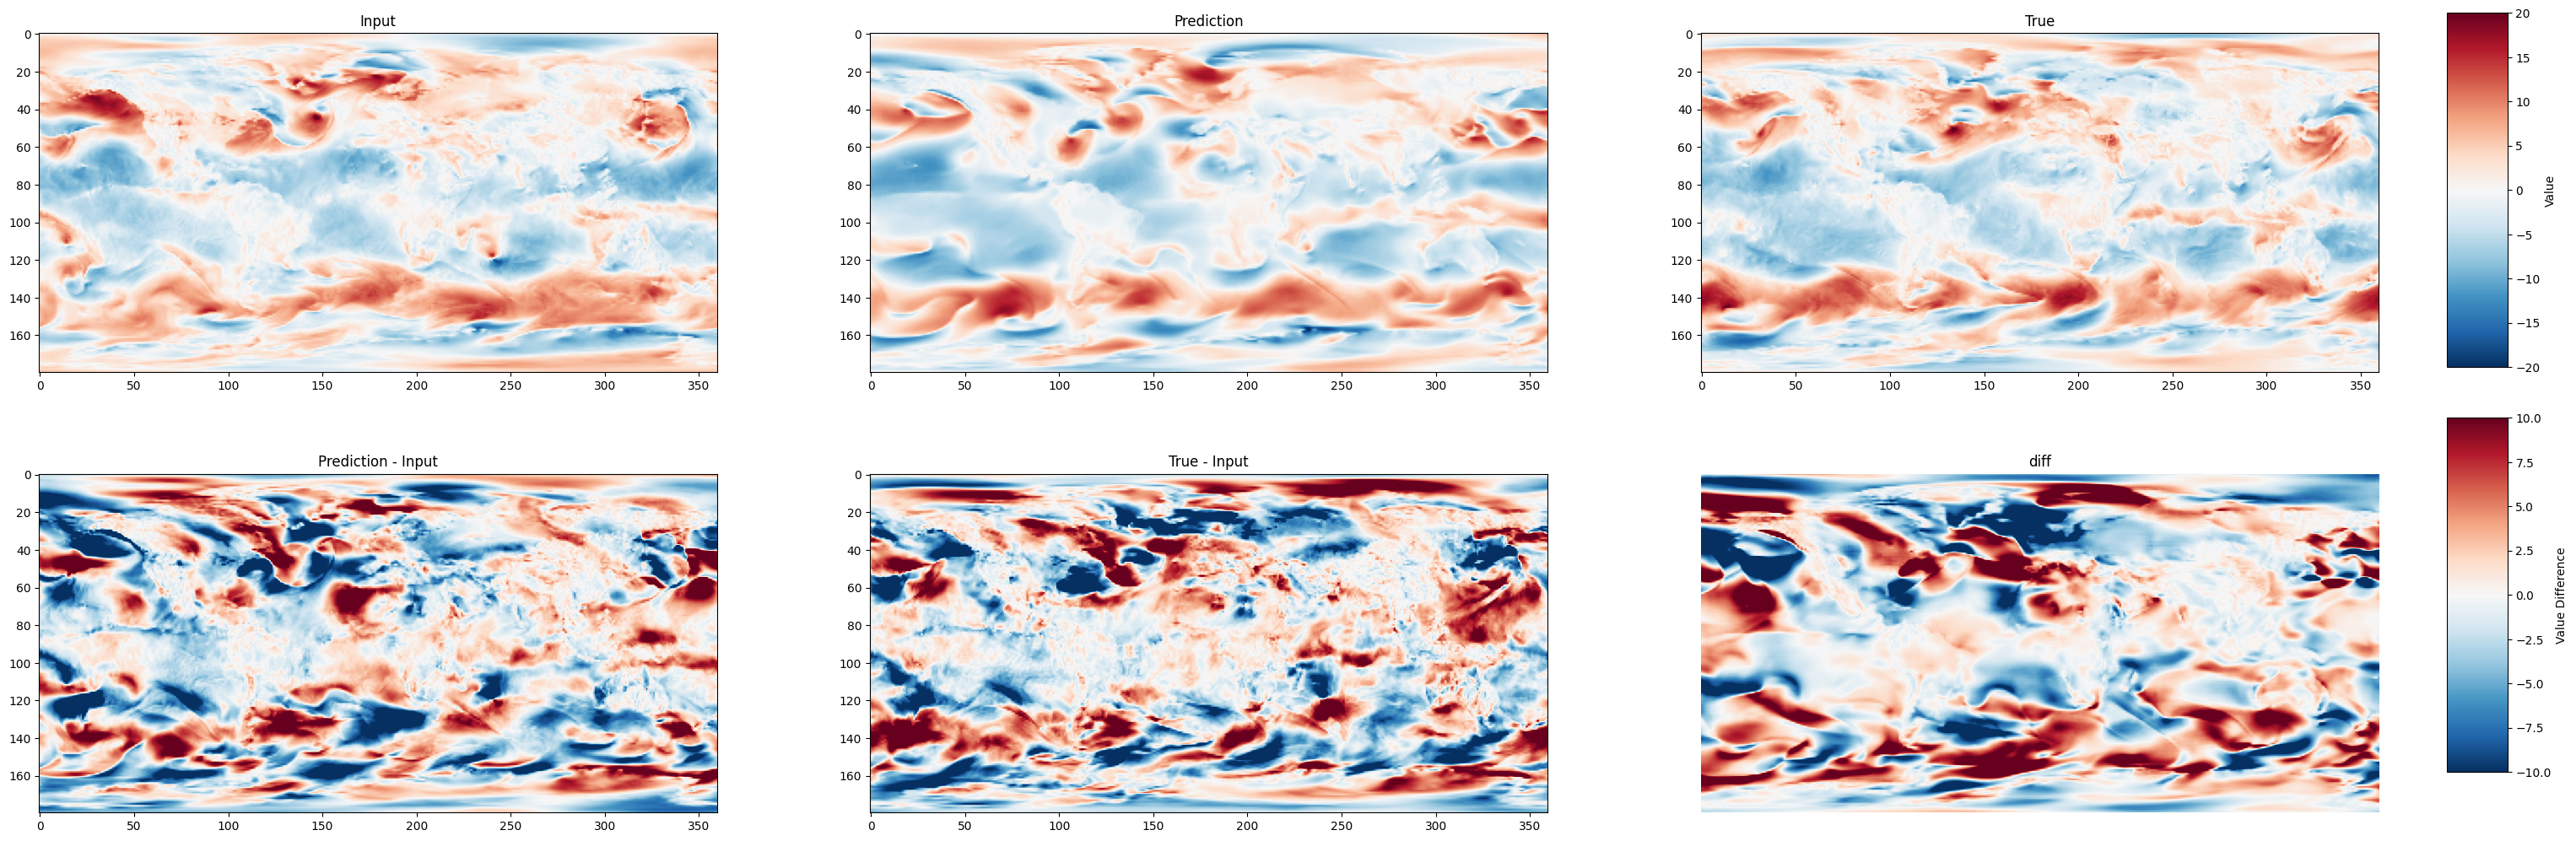

In [15]:
import matplotlib.pyplot as plt
import h5py
import torch
import torch.nn.functional as F
import numpy as np


def shift_image(data):
    width = data.shape[1]
    left_half = data[:, :width // 2]
    right_half = data[:, width // 2:]
    return np.concatenate((right_half, left_half), axis=1)


ds = h5py.File('/jizhicfs/easyluwu/gaoyuan/CVPR2026_coupler/coupler_1degree/exp_15_levels_202312/DSLCast/20250601-132533/results_forecasting_55ics_icml_0.h5')
ds1 = h5py.File('/apdcephfs_qy3/share_301734960/easyluwu/gy/PnP-Corrector_github/correction_agent/exp_15_levels_202312/DSLCast/20250601-132533/results_forecasting_55ics_icml_0512.h5')

# print(ds.keys())
time = 30
var = 65
ic = 0

print(ds['predicted'].shape, ds['ground_truth'].shape)


input = torch.tensor(ds['predicted'][ic, 0, var, :, :])
input = input.numpy()


pre = torch.tensor(ds['predicted'][ic, time, var, :, :])
pre = pre.numpy()
print('pre', np.mean(pre))

pre1 = torch.tensor(ds1['predicted'][ic, time, var, :, :])
pre1 = pre1.numpy()
print('pre1', np.mean(pre1))


tar = torch.tensor(ds['ground_truth'][ic, time, var, :, :])
tar = tar.numpy()

print('tar', np.mean(tar))

tar1 = torch.tensor(ds1['ground_truth'][ic, time, var, :, :])
tar1 = tar1.numpy()

print('tar1', np.mean(tar1))

print('t2m mse', np.mean((pre-tar)**2))


# preds = ds['predicted'][0, time, :, :, :]
# tars = ds['ground_truth'][0, time, :, :, :]
# mse = (preds - tars) ** 2
# print('162 vars mse', np.mean(mse))
value_range = 0


# min0 = -2500
# max0 = 2500
# min1 = -2500
# max1 = 2500


# min0 = 10000
# max0 = 500000
# min1 = -5000
# max1 = 5000

min0 = -20
max0 = 20
min1 = -10
max1 = 10

# min0 = 250
# max0 = 300
# min1 = -10
# max1 = 10

# min0 = -2
# max0 = 2
# min1 = -2
# max1 = 2

# min0 = 0.001
# max0 = 0.01
# min1 = -0.002
# max1 = 0.002


# min0 = 230000
# max0 = 240000
# min1 = -3000
# max1 = 3000

#mslp
# min0 = 96000
# max0 = 104000
# min1 = -3000
# max1 = 3000


if value_range == 0:
    # 设置绘图
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(36, 12))


    # 使用 imshow 绘制图像
    img_inputs = axes[0, 0].imshow(input, cmap='RdBu_r', vmin=min0, vmax=max0)
    axes[0, 0].set_title('Input')


    img_preds = axes[0, 1].imshow(pre, cmap='RdBu_r', vmin=min0, vmax=max0)
    axes[0, 1].set_title('Prediction')


    img_trues = axes[0, 2].imshow(tar, cmap='RdBu_r', vmin=min0, vmax=max0)
    axes[0, 2].set_title('True')


    img_diff_pred_input = axes[1, 0].imshow(pre - input, cmap='RdBu_r', vmin=min1, vmax=max1)
    axes[1, 0].set_title('Prediction - Input')


    img_diff_true_input = axes[1, 1].imshow(tar - input, cmap='RdBu_r', vmin=min1, vmax=max1)
    axes[1, 1].set_title('True - Input')


    img_diff = axes[1, 2].imshow(pre1 - pre, cmap='RdBu_r', vmin=min1, vmax=max1)
    axes[1, 2].set_title('diff')


    # 空白子图
    axes[1, 2].axis('off')


    # 添加第一行的颜色条
    cbar_ax1 = fig.add_axes([0.92, 0.55, 0.02, 0.35])  # 调整颜色条的位置和大小
    fig.colorbar(img_preds, cax=cbar_ax1, label='Value')


    # 添加第二行的颜色条
    cbar_ax2 = fig.add_axes([0.92, 0.15, 0.02, 0.35])  # 调整颜色条的位置和大小
    fig.colorbar(img_diff_pred_input, cax=cbar_ax2, label='Value Difference')


    # 调整子图间的空间以腾出放置颜色条的空间
    plt.subplots_adjust(right=0.9, hspace=0.3)

    plt.show()


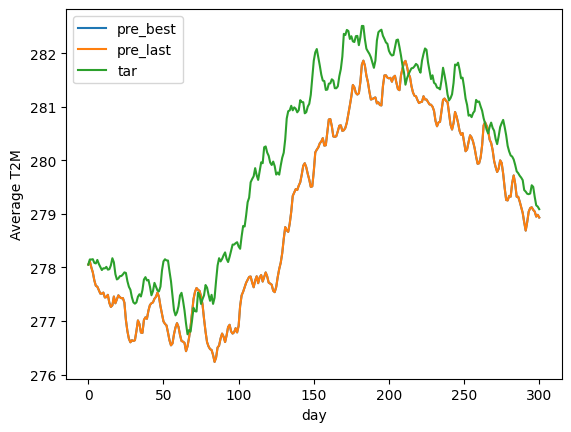

In [28]:
import matplotlib.pyplot as plt
import h5py
import numpy as np

ds_best = h5py.File('/jizhicfs/easyluwu/gaoyuan/CVPR2026_coupler/coupler_1degree/exp_15_levels_202312/DSLCast/20250601-132533/results_forecasting_55ics_icml.h5')
ds_last = h5py.File('/jizhicfs/easyluwu/gaoyuan/CVPR2026_coupler/coupler_1degree/exp_15_levels_202312/DSLCast/20250601-132533/results_forecasting_55ics_icml.h5')

# print(ds.keys())

ic = 0

data_pre_best = ds_best['predicted'][ic, :, 67, :, :]
data_pre_last = ds_last['predicted'][ic, :, 67, :, :]
data_tar = ds_last['ground_truth'][ic, :, 67, :, :]

avg_data_pre_best = np.mean(data_pre_best, axis=(1, 2))
avg_data_pre_last = np.mean(data_pre_last, axis=(1, 2))

avg_data_tar = np.mean(data_tar, axis=(1, 2))
# print(avg_data_pre_best.shape)
# print(avg_data_tar.shape)
# print(avg_data_pre_best[400], avg_data_tar[400])

plt.plot(avg_data_pre_best, label='pre_best')
plt.plot(avg_data_pre_last, label='pre_last')
plt.plot(avg_data_tar, label='tar')
plt.xlabel('day')
plt.ylabel('Average T2M')
# plt.title('xx')
plt.legend()
plt.show()


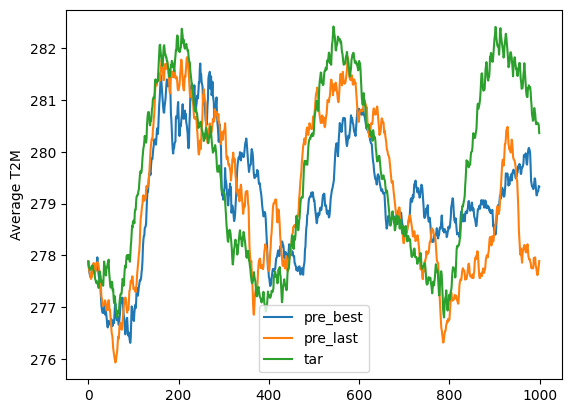

In [6]:
import matplotlib.pyplot as plt
import h5py
import numpy as np

ds_best = h5py.File('/jizhicfs/Prometheus/gaoyuan/llm/ft_local/triton_v2/triton_v2_atmos_forced_by_sst_dt_1day/exp_15_levels_202312/Triton/20250805-201109/autoregressive_predictions_2020_dt1_best.h5')
ds_last = h5py.File('/jizhicfs/Prometheus/gaoyuan/llm/ft_local/triton_v2/triton_v2_atmos_forced_by_sst_dt_1day/exp_15_levels_202312/Triton/20250805-201109/autoregressive_predictions_2020_dt1_last.h5')

# print(ds.keys())


data_pre_best = ds_best['predicted'][:, :, 67, :, :]
data_pre_last = ds_last['predicted'][:, :, 67, :, :]
data_tar = ds_last['ground_truth'][:, :, 67, :, :]

avg_data_pre_best = np.mean(data_pre_best, axis=(0, 2, 3))
avg_data_pre_last = np.mean(data_pre_last, axis=(0, 2, 3))

avg_data_tar = np.mean(data_tar, axis=(0, 2, 3))
# print(avg_data_pre_best.shape)
# print(avg_data_tar.shape)
# print(avg_data_pre_best[400], avg_data_tar[400])

plt.plot(avg_data_pre_best, label='pre_best', color='#1F77B4')  # Blue
plt.plot(avg_data_pre_last, label='pre_last', color='#FF7F0E')  # Orange
plt.plot(avg_data_tar, label='tar', color='#2CA02C')  # Green
plt.ylabel('Average T2M')
# plt.title('xx')
plt.legend()
plt.show()


In [9]:
import h5py
import numpy as np
import os

old_path = '/jizhicfs/easyluwu/gaoyuan/CVPR2026_coupler/coupler_1degree/exp_15_levels_202312/DSLCast/20250601-132533/results_forecasting_55ics_icml_0.h5'
new_path = '/jizhicfs/easyluwu/gaoyuan/CVPR2026_coupler/coupler_1degree/exp_15_levels_202312/DSLCast/20250601-132533/results_forecasting_55ics_icml.h5'

times = [0, 1, 2, 5, 10, 20, 50, 100, 200, 300]


def print_file_info(path):
    print("=" * 100)
    print("file:", path)
    print("exists:", os.path.exists(path))
    print("size GB:", os.path.getsize(path) / 1024**3)

    with h5py.File(path, "r") as f:
        print("keys:", list(f.keys()))
        for k in f.keys():
            print(k, "shape:", f[k].shape, "dtype:", f[k].dtype)


def compare_ic0(old_f, new_f, name, times, var_idx=None):
    old_ds = old_f[name]
    new_ds = new_f[name]

    print("\n" + "=" * 100)
    if var_idx is None:
        print(f"Compare {name}: old IC0 vs new IC0, all variables")
    else:
        print(f"Compare {name}: old IC0 vs new IC0, var_idx={var_idx}")

    T = min(old_ds.shape[1], new_ds.shape[1])

    for t in times:
        if t >= T:
            continue

        if var_idx is None:
            old_arr = old_ds[0, t].astype(np.float64)
            new_arr = new_ds[0, t].astype(np.float64)
        else:
            old_arr = old_ds[0, t, var_idx].astype(np.float64)
            new_arr = new_ds[0, t, var_idx].astype(np.float64)

        diff = new_arr - old_arr
        abs_diff = np.abs(diff)

        print(
            f"t={t:3d} | "
            f"mean_abs={np.mean(abs_diff):.10e} | "
            f"max_abs={np.max(abs_diff):.10e} | "
            f"mse={np.mean(diff ** 2):.10e} | "
            f"old_mean={np.mean(old_arr):.10e} | "
            f"new_mean={np.mean(new_arr):.10e}"
        )


def check_pred_gt_ic0(path, times):
    print("\n" + "=" * 100)
    print("Check pred vs gt in same file, IC0:", path)

    with h5py.File(path, "r") as f:
        pred = f["predicted"]
        gt = f["ground_truth"]

        T = pred.shape[1]

        for t in times:
            if t >= T:
                continue

            p = pred[0, t].astype(np.float64)
            g = gt[0, t].astype(np.float64)

            diff = p - g
            abs_diff = np.abs(diff)

            print(
                f"pred-gt t={t:3d} | "
                f"mean_abs={np.mean(abs_diff):.10e} | "
                f"max_abs={np.max(abs_diff):.10e} | "
                f"mse={np.mean(diff ** 2):.10e}"
            )


print_file_info(old_path)
print_file_info(new_path)

with h5py.File(old_path, "r") as old_f, h5py.File(new_path, "r") as new_f:
    # 1. 检查 old IC0 和 new IC0 的 ground truth 是否一致
    compare_ic0(old_f, new_f, "ground_truth", times)

    # 2. 检查 old IC0 和 new IC0 的 prediction 差异
    compare_ic0(old_f, new_f, "predicted", times)

    # 3. 单独检查 T2M，index=67
    compare_ic0(old_f, new_f, "predicted", times, var_idx=67)

    # 4. 单独检查 SSTa，index=138，如果你关心海洋反馈
    compare_ic0(old_f, new_f, "predicted", times, var_idx=138)

# 5. 检查各自文件内部 pred 和 gt 的关系
check_pred_gt_ic0(old_path, [0, 1])
check_pred_gt_ic0(new_path, [0, 1])

file: /jizhicfs/easyluwu/gaoyuan/CVPR2026_coupler/coupler_1degree/exp_15_levels_202312/DSLCast/20250601-132533/results_forecasting_55ics_icml_0.h5
exists: True
size GB: 1361.9638556614518
keys: ['ground_truth', 'predicted']
ground_truth shape: (55, 301, 162, 180, 360) dtype: float32
predicted shape: (55, 301, 162, 180, 360) dtype: float32
file: /jizhicfs/easyluwu/gaoyuan/CVPR2026_coupler/coupler_1degree/exp_15_levels_202312/DSLCast/20250601-132533/results_forecasting_55ics_icml.h5
exists: True
size GB: 24.762989349663258
keys: ['ground_truth', 'predicted']
ground_truth shape: (1, 301, 162, 180, 360) dtype: float32
predicted shape: (1, 301, 162, 180, 360) dtype: float32

Compare ground_truth: old IC0 vs new IC0, all variables
t=  0 | mean_abs=0.0000000000e+00 | max_abs=0.0000000000e+00 | mse=0.0000000000e+00 | old_mean=6.8803317232e+03 | new_mean=6.8803317232e+03
t=  1 | mean_abs=0.0000000000e+00 | max_abs=0.0000000000e+00 | mse=0.0000000000e+00 | old_mean=6.8823249167e+03 | new_mean=6.